In [34]:
# pip install wordcloud emoji nltk vaderSentiment

In [35]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import emoji


## Load WhatsApp chat

In [36]:
file_path="mabel.txt"
pattern=r"^(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2}\s?[APMapm]{0,2})\s-\s(.*?):\s(.*)"
rows=[]
with open(file_path,"r",encoding="utf-8") as f:
    for line in f:
        line=line.strip()
        m=re.match(pattern,line)
        if m:
            rows.append(m.groups())

df=pd.DataFrame(rows,columns=["Date","Time","User","Message"])
df["Datetime"]=pd.to_datetime(df["Date"]+" "+df["Time"],dayfirst=True,errors="coerce")
df=df.dropna()
df.head()

C:\Users\Paul\AppData\Local\Temp\ipykernel_13420\2284874436.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Datetime"]=pd.to_datetime(df["Date"]+" "+df["Time"],dayfirst=True,errors="coerce")


,Date,Time,User,Message,Datetime
0,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,2019-12-05 13:42:00
1,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,2019-12-05 13:42:00
2,05/12/19,1:42 pm,AR❤,Ramisha Rani K,2019-12-05 13:42:00
3,05/12/19,1:42 pm,Mabel Infoziant,Ok,2019-12-05 13:42:00
4,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,2019-12-05 13:42:00


## Preprocessing

In [37]:
df=df[~df['Message'].str.contains('<Media omitted>',na=False)]
df['MessageLength']=df['Message'].str.len()
df['Date']=df['Datetime'].dt.date
df['Month']=df['Datetime'].dt.month_name()
df['Hour']=df['Datetime'].dt.hour
df.head()

,Date,Time,User,Message,Datetime,MessageLength,Month,Hour
0,2019-12-05,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,2019-12-05 13:42:00,30,December,13
1,2019-12-05,1:42 pm,Mabel Infoziant,What’s your full name,2019-12-05 13:42:00,21,December,13
2,2019-12-05,1:42 pm,AR❤,Ramisha Rani K,2019-12-05 13:42:00,14,December,13
3,2019-12-05,1:42 pm,Mabel Infoziant,Ok,2019-12-05 13:42:00,2,December,13
4,2019-12-05,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,2019-12-05 13:42:00,22,December,13


## Basic Statistics

In [38]:
print("Total Messages:",len(df))
print("Users:",df['User'].nunique())
print(df['User'].value_counts())

Total Messages: 52
Users: 2
User
AR❤                29
Mabel Infoziant    23
Name: count, dtype: int64


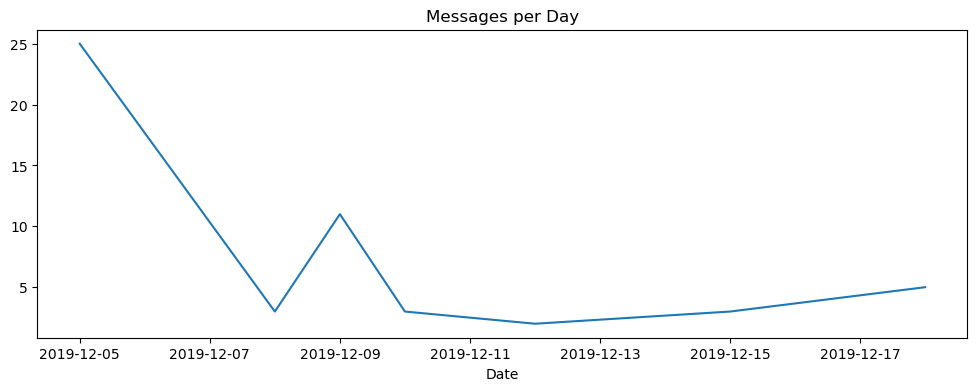

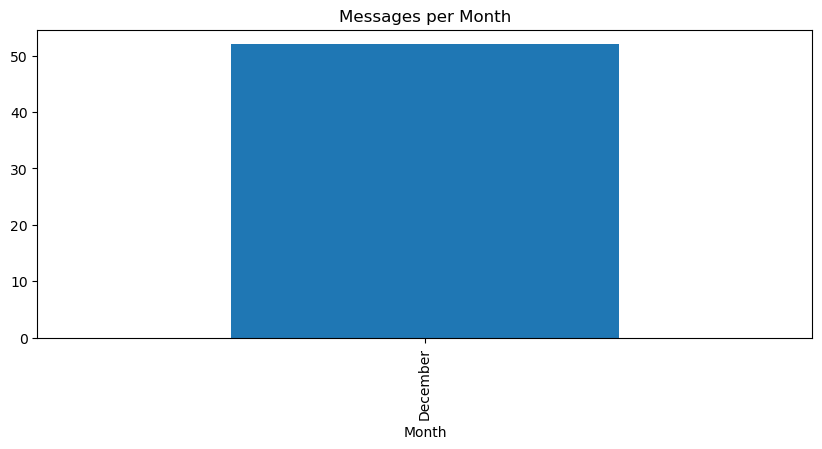

In [39]:
df.groupby("Date").size().plot(figsize=(12,4),title="Messages per Day")
plt.show()

df.groupby("Month").size().plot(kind="bar",figsize=(10,4),title="Messages per Month")
plt.show()

## Common Words

In [40]:
text=" ".join(df["Message"].astype(str))
words=[w.lower() for w in re.findall(r"\b[a-zA-Z]{3,}\b",text)]
Counter(words).most_common(20)

[('mam', 32),
 ('the', 18),
 ('will', 11),
 ('have', 9),
 ('can', 9),
 ('for', 6),
 ('you', 6),
 ('details', 6),
 ('with', 6),
 ('call', 6),
 ('your', 5),
 ('send', 5),
 ('and', 5),
 ('project', 5),
 ('office', 4),
 ('tomorrow', 4),
 ('vignesh', 4),
 ('that', 3),
 ('number', 3),
 ('ask', 3)]

## Emoji Analysis

In [41]:
emojis=[]
for msg in df['Message']:
    emojis.extend([c for c in msg if c in emoji.EMOJI_DATA])
Counter(emojis).most_common(15)

[('👍', 1), ('🏻', 1)]

## Sentiment Analysis

In [42]:
analyzer=SentimentIntensityAnalyzer()

def sentiment(msg):
    score=analyzer.polarity_scores(str(msg))['compound']
    if score>=0.05:
        return 'Positive'
    elif score<=-0.05:
        return 'Negative'
    return 'Neutral'

df['Sentiment']=df['Message'].apply(sentiment)
df.head()

,Date,Time,User,Message,Datetime,MessageLength,Month,Hour,Sentiment
0,2019-12-05,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,2019-12-05 13:42:00,30,December,13,Neutral
1,2019-12-05,1:42 pm,Mabel Infoziant,What’s your full name,2019-12-05 13:42:00,21,December,13,Neutral
2,2019-12-05,1:42 pm,AR❤,Ramisha Rani K,2019-12-05 13:42:00,14,December,13,Neutral
3,2019-12-05,1:42 pm,Mabel Infoziant,Ok,2019-12-05 13:42:00,2,December,13,Positive
4,2019-12-05,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,2019-12-05 13:42:00,22,December,13,Neutral


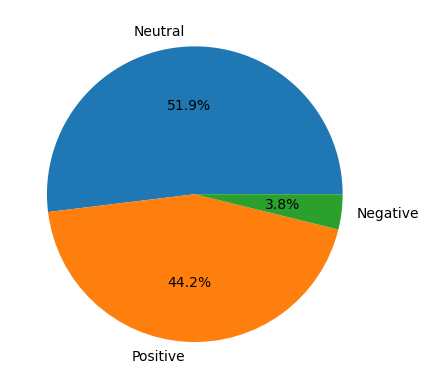

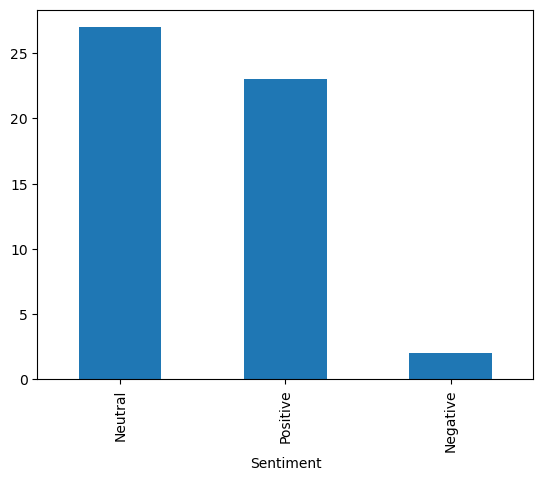

In [43]:
df['Sentiment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.ylabel("")
plt.show()

df['Sentiment'].value_counts().plot(kind='bar')
plt.show()

## Topic Modelling

In [44]:
vectorizer=CountVectorizer(stop_words='english',max_features=1000)
X=vectorizer.fit_transform(df['Message'])
lda=LatentDirichletAllocation(n_components=5,random_state=42)
lda.fit(X)
terms=vectorizer.get_feature_names_out()

for idx,topic in enumerate(lda.components_):
    print("\nTopic",idx+1)
    print([terms[i] for i in topic.argsort()[-10:]])



Topic 1
['diabetes', 'hi', 'start', 'abstracts', 'sent', 'send', 'project', 'details', 'vignesh', 'mam']

Topic 2
['phone', 'students', 'share', 'send', 'number', 'hi', 'yes', 'church', 'details', 'need']

Topic 3
['arun', 'praise', 'issue', 'soon', 'number', 'kk', 'meeting', 'ask', 'office', 'mam']

Topic 4
['forward', 'talk', '30', '10', 'today', 'ramisha', 'yeah', 'sure', 'ok', 'mam']

Topic 5
['comfortable', 'negotiation', 'think', 'read', 'abstract', 'just', 'finiliaze', 'project', 'tomorrow', 'mam']


## Word Cloud

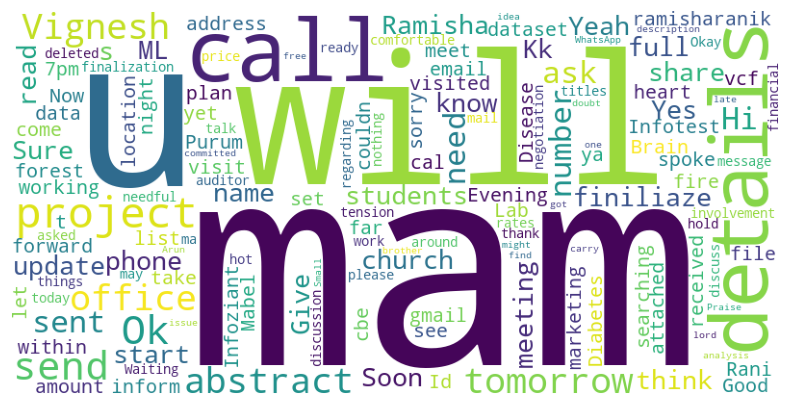

In [45]:
wc=WordCloud(width=800,height=400,background_color='white').generate(text)
plt.figure(figsize=(12,5))
plt.imshow(wc)
plt.axis('off')
plt.show()

## Positive Word Cloud

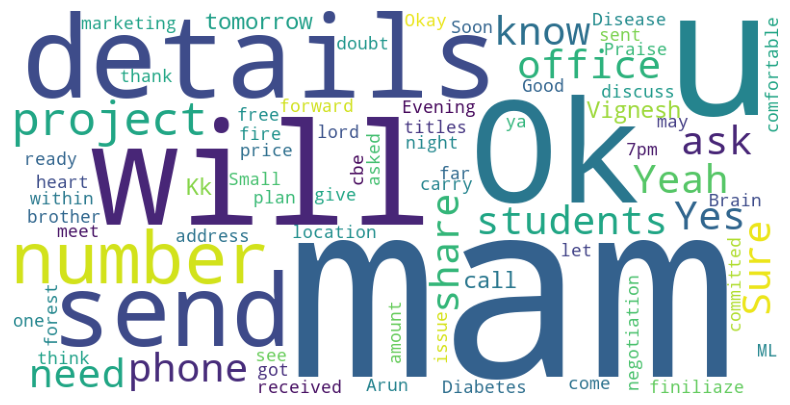

In [46]:
pos=' '.join(df[df.Sentiment=='Positive']['Message'].astype(str))
if pos:
    wc=WordCloud(width=800,height=400,background_color='white').generate(pos)
    plt.figure(figsize=(12,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()

## Negative Word Cloud

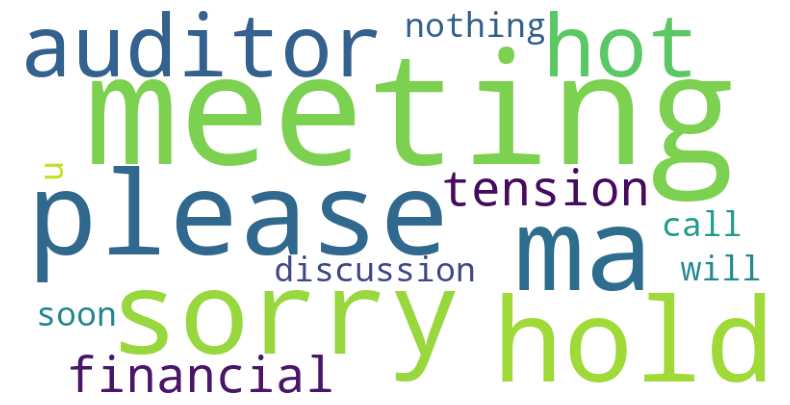

In [47]:
neg=' '.join(df[df.Sentiment=='Negative']['Message'].astype(str))
if neg:
    wc=WordCloud(width=800,height=400,background_color='white').generate(neg)
    plt.figure(figsize=(12,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.show()